# Face Recognition Using Eigenfaces and Pattern Classification

**DSCD612 Pattern Recognition — Project 3**

Daniel Kpakpo Adotey · ID 22424924 · dkadotey@st.ug.edu.gh
University of Ghana, MPhil/MSc Data Science, Second Semester 2025/2026

---

## 1. Problem formulation

Face recognition is a closed-set identification problem: given an image of a
face known to belong to one of $C$ enrolled individuals, decide which one.
Treated naively it is a classification problem in a space of pixel
intensities, and that space is the difficulty. A $64 \times 64$ greyscale
image is a point in $\mathbb{R}^{4096}$, yet the dataset used here contains
only 400 such points. With 4096 features and 400 observations the sample
covariance matrix is singular, nearest-neighbour distances concentrate, and
any method that estimates a per-class density is hopeless.

The observation that makes the problem tractable is that face images do not
fill $\mathbb{R}^{4096}$. They lie on a far lower-dimensional structure,
because faces share a common geometry: two eyes above a nose above a mouth,
roughly aligned. Turk and Pentland's *Eigenfaces* method (1991) exploits this
by finding the linear subspace that captures most of the variation across a
set of faces, and performing recognition inside it.

This notebook implements that pipeline from first principles and uses it to
answer the project's central research question:

> **How much dimensionality can be removed from facial images before
> identity-discriminating information is significantly lost?**

The question is sharper than it first appears, because "information" can be
measured two ways — by *reconstruction* (how much pixel variance is retained)
and by *discrimination* (how well identities can still be told apart). A
central finding below is that these two measures disagree by roughly a factor
of five, and that the disagreement has a clear cause.

## 2. Dataset

The **Olivetti Research Laboratory (ORL) face database**, distributed with
scikit-learn as `fetch_olivetti_faces`. It contains 400 greyscale images of
40 distinct subjects, 10 images each, captured at AT&T Laboratories Cambridge
between 1992 and 1994. Images are $64 \times 64$ pixels, quantised to 256
grey levels and supplied normalised to $[0, 1]$.

Within a subject the ten images vary in lighting, facial expression (open or
closed eyes, smiling or not), and facial details (glasses or no glasses).
All images were taken against a dark homogeneous background with the subject
upright and frontal, with tolerance for some side movement. The faces are
already cropped and roughly aligned, which means this study measures the
recognition method rather than a face *detection* front end.

The dataset is well matched to the project: 40 classes is a genuine multiclass
problem, and 10 images per subject is enough to separate training from test
while remaining small enough that the small-sample behaviour of PCA — the
interesting regime — is visible.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import eigenfaces as ef  # noqa: E402

FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
RESULTS = {}

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
print(f"numpy {np.__version__}")

numpy 2.5.0


### 2.1 Loading and representing the data

### Task (a) — Face representation

Each normalised greyscale image is flattened in row-major order into a
vector

$$x_i \in \mathbb{R}^d, \qquad d = 64 \times 64 = 4096,$$

and the images are stacked into the face matrix

$$X = [x_1, x_2, \ldots, x_N]^T \in \mathbb{R}^{N \times d}, \qquad N = 400.$$

Flattening discards the 2-D neighbourhood structure of the image: pixel
$(r, c)$ and pixel $(r+1, c)$ are adjacent on the face but 64 positions apart
in the vector. PCA does not need that structure — it recovers spatial
correlation from the data itself, which is why the eigenvectors turn out to
look like faces rather than noise.

In [2]:
faces = fetch_olivetti_faces(data_home=str(ROOT / "data"), shuffle=False)
X = faces.data.astype(np.float64)      # (400, 4096)
y = faces.target                        # (400,) subject id in 0..39
images = faces.images                   # (400, 64, 64)

N, d = X.shape
n_classes = len(np.unique(y))
print(f"Face matrix X: {X.shape}   (N = {N} observations, d = {d} features)")
print(f"Subjects: {n_classes}, images per subject: {np.bincount(y).min()}")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]   dtype: {X.dtype}")
print(f"Observations per feature: {N/d:.3f}  <- severely under-determined")

Face matrix X: (400, 4096)   (N = 400 observations, d = 4096 features)
Subjects: 40, images per subject: 10
Pixel range: [0.000, 1.000]   dtype: float64
Observations per feature: 0.098  <- severely under-determined


The final line states the core difficulty numerically. There are roughly ten
times more features than observations. Every conclusion below is shaped by
this ratio.

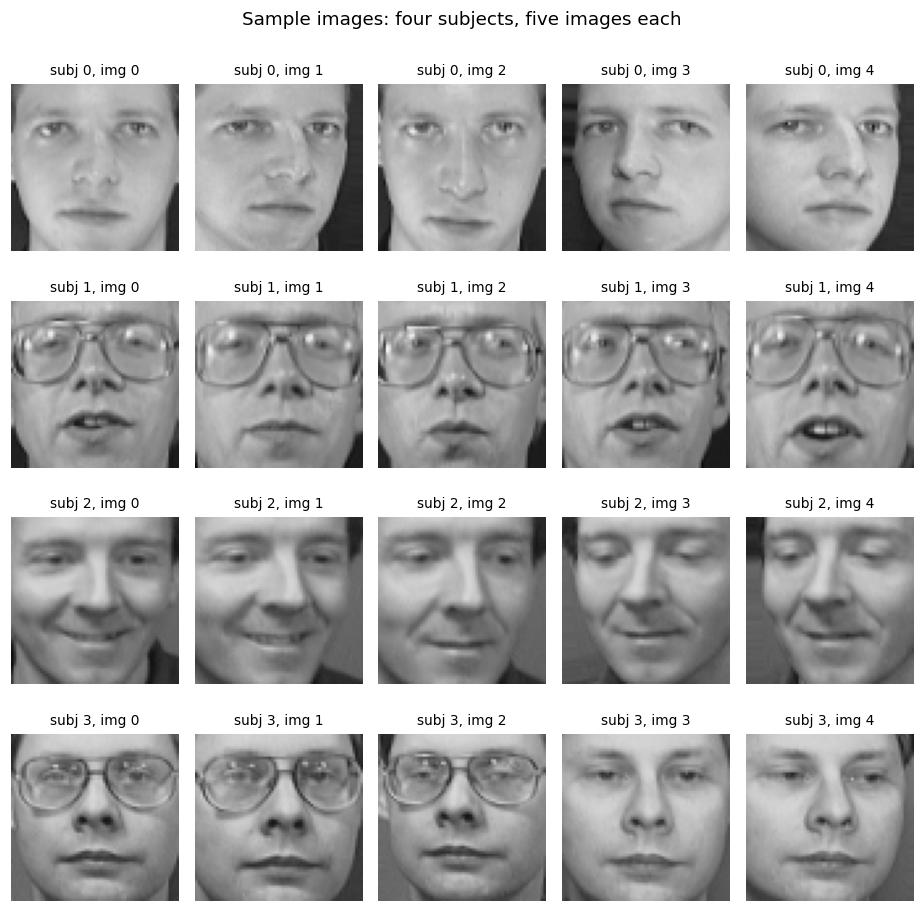

In [3]:
fig = ef.image_grid(
    [X[i * 10 + j] for i in range(4) for j in range(5)],
    titles=[f"subj {i}, img {j}" for i in range(4) for j in range(5)],
    ncols=5,
    suptitle="Sample images: four subjects, five images each",
    path=FIG / "01_samples.png",
)
plt.show()

Within a row (one subject) the variation from expression and lighting is
clearly visible. This within-class variation is what the classifier must
tolerate; the between-class variation is what it must exploit.

### 2.2 Exploratory statistical analysis

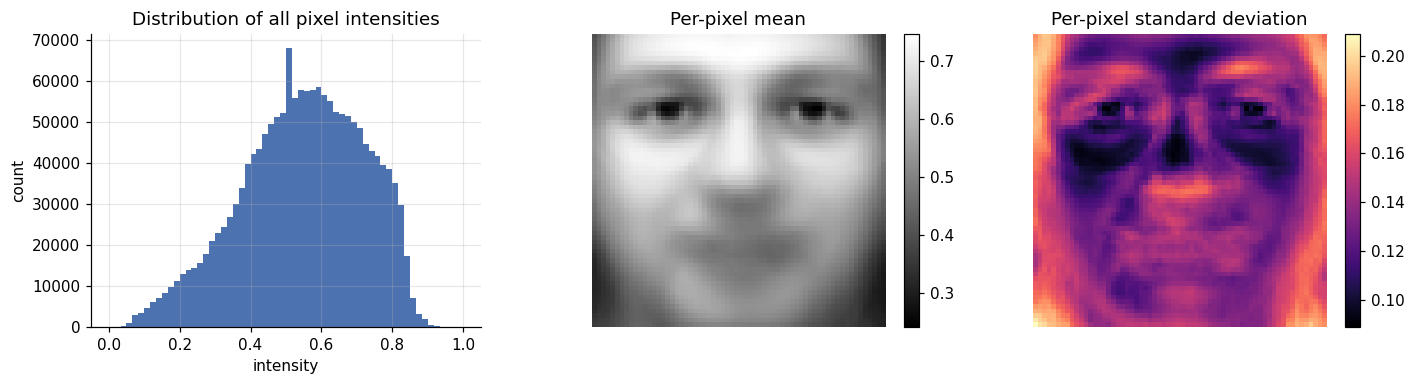

Mean intensity 0.547, sd 0.173
Per-pixel sd ranges from 0.089 to 0.209


In [4]:
pixel_mean = X.mean(axis=0)
pixel_std = X.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(X.ravel(), bins=60, color="#4C72B0")
axes[0].set(title="Distribution of all pixel intensities",
            xlabel="intensity", ylabel="count")
im1 = axes[1].imshow(pixel_mean.reshape(64, 64), cmap="gray")
axes[1].set_title("Per-pixel mean")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(pixel_std.reshape(64, 64), cmap="magma")
axes[2].set_title("Per-pixel standard deviation")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
fig.tight_layout()
ef.save(fig, FIG / "02_pixel_stats.png")
plt.show()

print(f"Mean intensity {X.mean():.3f}, sd {X.std():.3f}")
print(f"Per-pixel sd ranges from {pixel_std.min():.3f} to {pixel_std.max():.3f}")

The standard-deviation map is informative: variance is concentrated around
the eyes, the hairline and the jaw outline, and is low across the forehead,
cheeks and background. Pixels differ enormously in how much they contribute,
which is the first indication that a small number of well-chosen directions
could capture most of the structure.

Neighbouring pixels are also strongly correlated. Sampling a subset of pixels
and examining their correlation matrix makes the redundancy explicit.

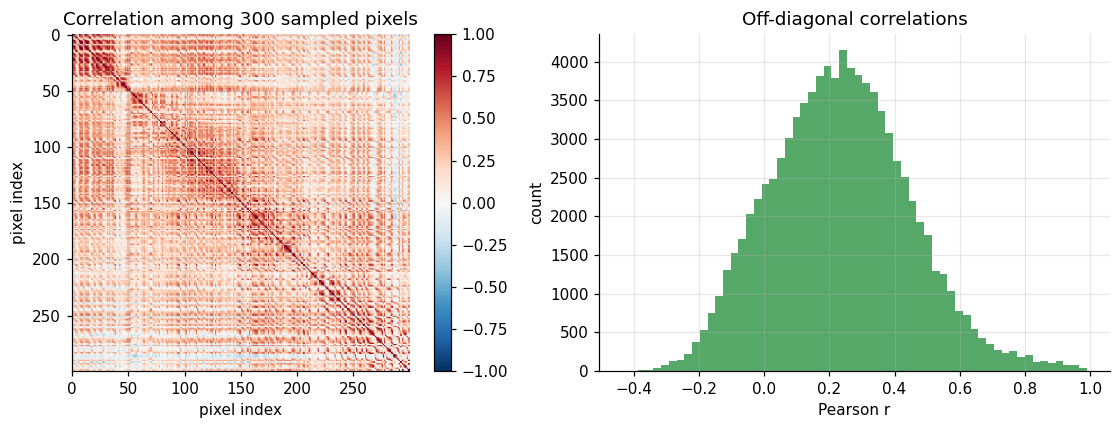

Mean |r| between distinct pixels: 0.260
Fraction of pixel pairs with |r| > 0.5: 10.4%


In [5]:
rng_probe = np.random.default_rng(RANDOM_STATE)
probe = np.sort(rng_probe.choice(d, size=300, replace=False))
corr = np.corrcoef(X[:, probe].T)
off_diag = corr[~np.eye(len(probe), dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set(title="Correlation among 300 sampled pixels",
            xlabel="pixel index", ylabel="pixel index")
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].hist(off_diag, bins=60, color="#55A868")
axes[1].set(title="Off-diagonal correlations",
            xlabel="Pearson r", ylabel="count")
fig.tight_layout()
ef.save(fig, FIG / "03_correlation.png")
plt.show()

frac_strong = np.mean(np.abs(off_diag) > 0.5)
print(f"Mean |r| between distinct pixels: {np.abs(off_diag).mean():.3f}")
print(f"Fraction of pixel pairs with |r| > 0.5: {frac_strong:.1%}")
RESULTS["mean_abs_pixel_corr"] = float(np.abs(off_diag).mean())
RESULTS["frac_pixel_pairs_r_gt_0.5"] = float(frac_strong)

The 4096 pixel features carry far less than 4096 features' worth of
independent information. PCA is the tool that converts that redundancy into a
smaller representation.

### 2.3 The mean face

$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$$

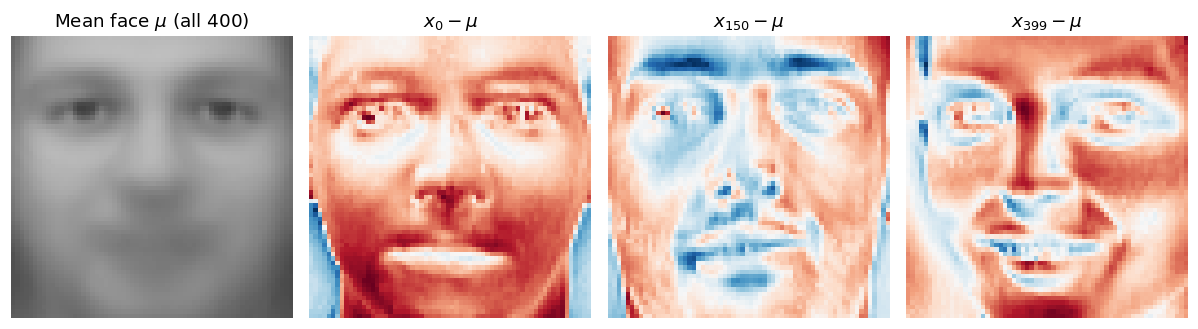

In [6]:
mean_face_all = X.mean(axis=0)

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
axes[0].imshow(mean_face_all.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Mean face $\\mu$ (all 400)")
for ax, i in zip(axes[1:], [0, 150, 399]):
    ax.imshow((X[i] - mean_face_all).reshape(64, 64), cmap="RdBu_r")
    ax.set_title(f"$x_{{{i}}} - \\mu$")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
ef.save(fig, FIG / "04_mean_face.png")
plt.show()

The mean face is a blurred, generic frontal face — the average of 40 people
retains the shared geometry and washes out individual detail. The
mean-centred images to its right show what remains once that shared structure
is subtracted: precisely the identity- and condition-specific deviations that
PCA will model. Mean-centring is not cosmetic. Without it the first principal
component would simply point along $\mu$, spending the most valuable
direction on information common to every image and therefore useless for
telling people apart.

---
## 3. Mathematical development

### 3.1 Principal Component Analysis

Let $A = X - \mathbf{1}\mu^T$ be the mean-centred data matrix. The sample
covariance matrix is

$$\Sigma = \frac{1}{N-1}\sum_{i=1}^{N}(x_i - \mu)(x_i - \mu)^T
         = \frac{1}{N-1}A^T A \;\in\; \mathbb{R}^{d \times d}.$$

PCA seeks the unit direction $v$ along which the projected data has maximum
variance. The variance of the projection $A v$ is $v^T \Sigma v$, so the
problem is

$$\max_{v} \; v^T \Sigma v \quad \text{subject to} \quad v^T v = 1 .$$

Introducing a Lagrange multiplier $\lambda$ gives
$\mathcal{L}(v, \lambda) = v^T \Sigma v - \lambda(v^T v - 1)$, and setting
$\partial \mathcal{L} / \partial v = 0$ yields

$$\boxed{\;\Sigma v_i = \lambda_i v_i\;}$$

the eigenvalue problem. The stationary points of the projected variance are
exactly the eigenvectors of $\Sigma$, and since $v_i^T \Sigma v_i = \lambda_i$,
the eigenvalue *is* the variance captured along that direction. Ordering
$\lambda_1 \ge \lambda_2 \ge \cdots \ge 0$ and keeping the top $k$
eigenvectors as columns of $W_k \in \mathbb{R}^{d \times k}$ gives the
rank-$k$ subspace that minimises the expected squared reconstruction error —
the Eckart–Young theorem. $\Sigma$ is real and symmetric, so its eigenvectors
are orthogonal and $W_k^T W_k = I_k$.

### 3.2 The snapshot trick, and why it is necessary here

$\Sigma$ is $4096 \times 4096$. Forming it costs 16.8 million entries and
eigendecomposing it costs $O(d^3) \approx 7 \times 10^{10}$ operations. Worse,
it is **guaranteed singular**: it is a sum of $N = 280$ (training) rank-one
terms subject to one linear constraint, so
$\operatorname{rank}(\Sigma) \le N - 1 = 279$. At most 279 of its 4096
eigenvalues are non-zero, and computing the other 3817 is wasted effort on
numerical noise.

Turk and Pentland's observation avoids this. Consider instead the much
smaller Gram matrix

$$G = \frac{1}{N-1} A A^T \;\in\; \mathbb{R}^{N \times N}.$$

If $G u_i = \lambda_i u_i$, then left-multiplying by $A^T$ gives

$$\frac{1}{N-1}A^T A A^T u_i = \lambda_i A^T u_i
\quad\Longleftrightarrow\quad
\Sigma \, (A^T u_i) = \lambda_i \, (A^T u_i).$$

So $A^T u_i$ is an eigenvector of $\Sigma$ with the **same** eigenvalue
$\lambda_i$. The non-zero part of the spectrum of the $4096 \times 4096$
covariance matrix is obtained from a $280 \times 280$ eigenproblem — a
reduction of roughly three orders of magnitude in cost. The resulting vectors
are not unit-norm, so each is normalised: $v_i = A^T u_i / \|A^T u_i\|$.

### 3.3 Why the eigenvectors are "Eigenfaces"

Each $v_i$ is a vector in $\mathbb{R}^{4096}$ — the same space the images
live in. It can therefore be reshaped to $64 \times 64$ and displayed as an
image. What it displays is a *pattern of deviation from the mean face*: a
coordinated way in which faces in this population differ from the average.
Because it is built as a linear combination of the training faces
($v_i \propto A^T u_i = \sum_j u_{ij} (x_j - \mu)$), it inherits their
face-like spatial structure. Hence the name.

Every face is then written as

$$x \approx \mu + \sum_{j=1}^{k} z_j v_j , \qquad z = W_k^T(x - \mu),$$

an identity-specific recipe of $k$ coefficients over a shared basis of
face-shaped ingredients.

### 3.4 Implementation

In [7]:
class EigenfacePCA:
    """PCA via the snapshot (Gram matrix) trick, implemented from scratch.

    Fits on the mean-centred training images and exposes the standard
    project / reconstruct operations. No decomposition routine from
    scikit-learn is used; only numpy's symmetric eigensolver.
    """

    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        n = X.shape[0]
        self.mean_ = X.mean(axis=0)
        A = X - self.mean_

        # Gram matrix: n x n rather than d x d
        G = (A @ A.T) / (n - 1)

        # eigh is used because G is real symmetric: it returns real
        # eigenvalues in ascending order and orthonormal eigenvectors.
        eigvals, U = np.linalg.eigh(G)
        order = np.argsort(eigvals)[::-1]
        eigvals, U = eigvals[order], U[:, order]

        # Rank is at most n - 1; tiny or negative values are numerical noise.
        tol = max(n, X.shape[1]) * np.finfo(np.float64).eps * max(eigvals[0], 0)
        keep = eigvals > max(tol, 1e-12)

        # Map back to the d-dimensional space and normalise to unit length.
        V = A.T @ U[:, keep]
        V /= np.linalg.norm(V, axis=0, keepdims=True)

        self.eigenvalues_ = eigvals[keep]
        self.components_ = V                       # (d, n_kept)
        self.n_components_ = V.shape[1]
        self.explained_variance_ratio_ = (
            self.eigenvalues_ / self.eigenvalues_.sum()
        )
        return self

    def _W(self, k=None):
        k = k or self.n_components or self.n_components_
        return self.components_[:, :k]

    def transform(self, X, k=None):
        """z = W^T (x - mu)"""
        return (np.asarray(X, dtype=np.float64) - self.mean_) @ self._W(k)

    def inverse_transform(self, Z, k=None):
        """x_hat = mu + W z"""
        return Z @ self._W(k).T + self.mean_

    def reconstruct(self, X, k=None):
        return self.inverse_transform(self.transform(X, k), k)

### 3.5 Correctness check

The implementation is verified against scikit-learn's `PCA` with the exact
(`full` SVD) solver. Eigenvalues must agree, and each eigenvector must agree
up to sign, since $v$ and $-v$ describe the same axis.

In [8]:
_pca_check = EigenfacePCA().fit(X)
_sk = PCA(n_components=100, svd_solver="full").fit(X)

eig_err = np.max(
    np.abs(_sk.explained_variance_ - _pca_check.eigenvalues_[:100])
    / _pca_check.eigenvalues_[:100]
)
vec_dot = np.abs((_sk.components_ * _pca_check.components_[:, :100].T).sum(axis=1))
recon_err = np.abs(
    _pca_check.reconstruct(X, 100)
    - (_sk.transform(X) @ _sk.components_ + _sk.mean_)
).max()

print(f"Components recovered            : {_pca_check.n_components_} (expected <= {N-1})")
print(f"Max relative eigenvalue error   : {eig_err:.2e}")
print(f"Min |dot product| of eigenvectors: {vec_dot.min():.10f}  (1.0 = identical axis)")
print(f"Max reconstruction difference   : {recon_err:.2e}")
assert eig_err < 1e-9 and vec_dot.min() > 1 - 1e-6
print("\nFrom-scratch PCA agrees with scikit-learn to machine precision.")

Components recovered            : 399 (expected <= 399)
Max relative eigenvalue error   : 4.99e-15
Min |dot product| of eigenvectors: 1.0000000000  (1.0 = identical axis)
Max reconstruction difference   : 1.55e-14

From-scratch PCA agrees with scikit-learn to machine precision.


In [9]:
t0 = time.perf_counter()
EigenfacePCA().fit(X)
t_snapshot = time.perf_counter() - t0

t0 = time.perf_counter()
_cov = np.cov(X - X.mean(0), rowvar=False)
np.linalg.eigh(_cov)
t_direct = time.perf_counter() - t0

print(f"Snapshot trick (400x400 eigenproblem) : {t_snapshot:.3f} s")
print(f"Direct covariance (4096x4096)         : {t_direct:.3f} s")
print(f"Speed-up: {t_direct/t_snapshot:.1f}x")
RESULTS["time_snapshot_s"] = t_snapshot
RESULTS["time_direct_s"] = t_direct
RESULTS["snapshot_speedup"] = t_direct / t_snapshot

Snapshot trick (400x400 eigenproblem) : 0.021 s
Direct covariance (4096x4096)         : 13.284 s
Speed-up: 645.0x


---
## 4. Experimental design

Three decisions govern every number reported below.

**Subject-stratified splitting.** Each of the 40 subjects contributes
$n_{\text{train}}$ images to the training set and the remainder to the test
set. A uniformly random split would leave some subjects with no training
images at all, making them unidentifiable by construction and confounding the
measurement. The default is 7 train / 3 test per subject: $N_{\text{train}} =
280$, $N_{\text{test}} = 120$.

**PCA is fitted on training data only.** The mean face $\mu$ and the
eigenfaces $W$ are estimated from the training images; test images are
projected with those fixed parameters. Fitting PCA on all 400 images before
splitting is a subtle but real form of information leakage — the basis would
be partly built from the images it is later evaluated on — and it inflates
reported accuracy. This is enforced throughout.

**Repetition over splits.** With only 120 test images, a single split has a
standard error of roughly 2.7 percentage points at 90% accuracy. Every curve
below is averaged over `N_SPLITS` independent splits and reported with its
standard deviation, so that differences between configurations can be judged
against the noise.

In [10]:
N_SPLITS = 10
N_TRAIN_PER_SUBJECT = 7

splits = []
for s in range(N_SPLITS):
    rng = np.random.default_rng(1000 + s)
    splits.append(ef.subject_split(y, N_TRAIN_PER_SUBJECT, rng))

tr0, te0 = splits[0]
X_train, X_test = X[tr0], X[te0]
y_train, y_test = y[tr0], y[te0]

print(f"Splits: {N_SPLITS}, each {N_TRAIN_PER_SUBJECT} train / "
      f"{10 - N_TRAIN_PER_SUBJECT} test images per subject")
print(f"Reference split -> train {X_train.shape}, test {X_test.shape}")
print(f"Every subject present in training set: "
      f"{len(np.unique(y_train)) == n_classes}")
print(f"No image appears in both sets: {len(set(tr0) & set(te0)) == 0}")
print(f"Max usable components = N_train - 1 = {len(X_train) - 1}")

Splits: 10, each 7 train / 3 test images per subject
Reference split -> train (280, 4096), test (120, 4096)
Every subject present in training set: True
No image appears in both sets: True
Max usable components = N_train - 1 = 279


---
## 5. Eigenface extraction

### Task (b) — Eigenfaces

PCA is fitted on the 280 training images. The mean face and the leading
eigenvectors are displayed below.

In [11]:
pca = EigenfacePCA().fit(X_train)
print(f"Non-zero components: {pca.n_components_}  "
      f"(rank bound N_train - 1 = {len(X_train) - 1})")
print(f"Largest eigenvalue  : {pca.eigenvalues_[0]:.4f}")
print(f"Smallest kept       : {pca.eigenvalues_[-1]:.3e}")
print(f"Condition number    : {pca.eigenvalues_[0]/pca.eigenvalues_[-1]:.1f}")

Non-zero components: 279  (rank bound N_train - 1 = 279)
Largest eigenvalue  : 18.5541
Smallest kept       : 3.260e-03
Condition number    : 5691.7


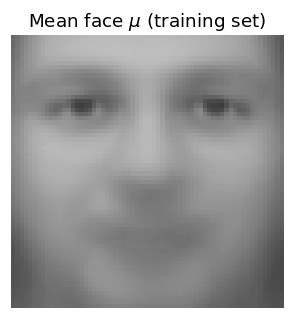

In [12]:
fig, ax = plt.subplots(figsize=(3.2, 3.4))
ax.imshow(pca.mean_.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
ax.set_title("Mean face $\\mu$ (training set)")
ax.axis("off")
ef.save(fig, FIG / "05_mean_face_train.png")
plt.show()

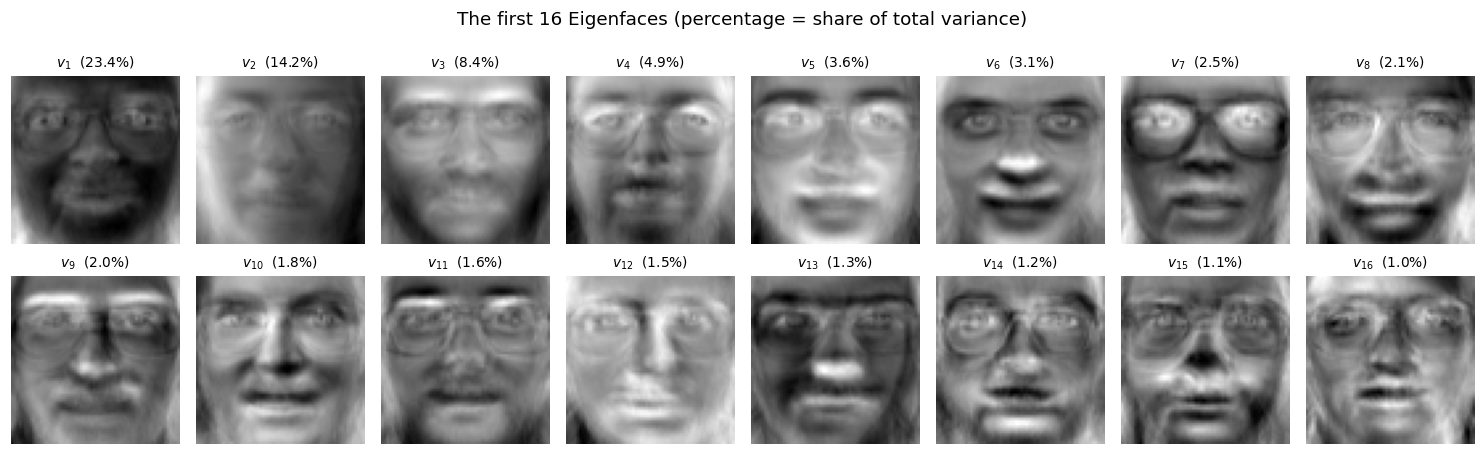

In [13]:
fig = ef.image_grid(
    [pca.components_[:, i] for i in range(16)],
    titles=[f"$v_{{{i+1}}}$  ({pca.explained_variance_ratio_[i]:.1%})"
            for i in range(16)],
    ncols=8,
    normalise=True,
    suptitle="The first 16 Eigenfaces (percentage = share of total variance)",
    path=FIG / "06_eigenfaces.png",
)
plt.show()

These images repay careful reading, because they show what PCA has actually
discovered without ever being told what a face is.

- The first three components are low in spatial frequency and describe
  whole-image photometric structure rather than facial detail. $v_1$ is a
  broad contrast pattern separating the brow and eye band from the rest of
  the face; $v_2$ is close to flat, encoding the overall luminance level of
  the image; $v_3$ carries a top-to-bottom intensity gradient, bright across
  the forehead and dark towards the chin. None of these describes who the
  person is. They describe how the image was lit and exposed.
- From $v_4$ onwards recognisable facial structure appears: spectacle frames,
  the hairline, moustaches, and changes around the mouth between neutral and
  smiling expressions.
- Later eigenfaces become progressively more localised and higher in spatial
  frequency. These carry identity information but also, as $i$ grows,
  sampling noise specific to these particular 280 training images.

The claim that the leading components encode illumination rather than
identity is asserted here only from visual inspection, which is weak
evidence. Section 10.2 tests it directly by perturbing the lighting of the
test images and measuring what happens when those three components are
discarded.

The ordering is the important point: variance and identity information are
**not** the same thing, and PCA optimises the former.

### 5.1 Spectrum and explained variance

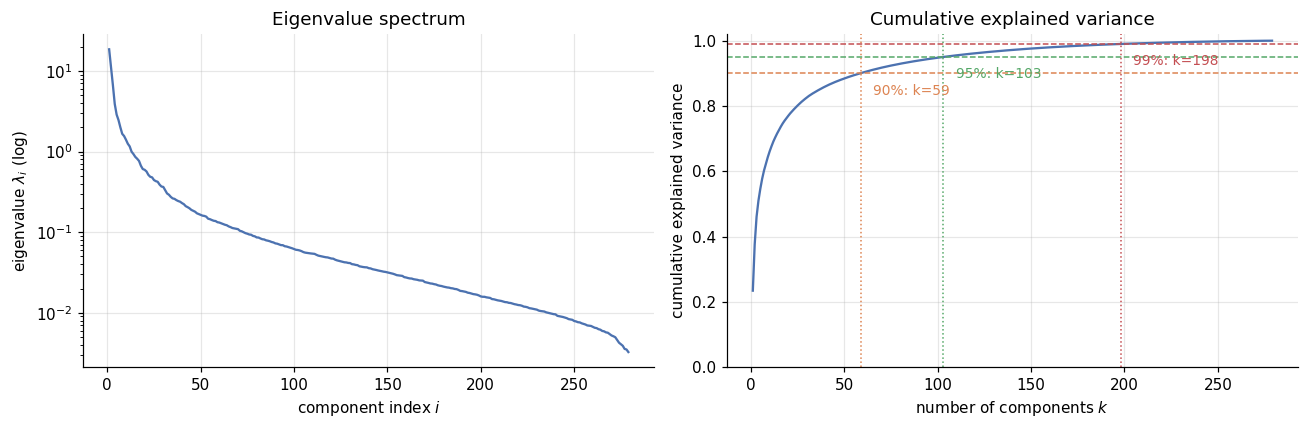

90% of variance requires  59 components (1.44% of the original 4096 dimensions)
95% of variance requires 103 components (2.51% of the original 4096 dimensions)
99% of variance requires 198 components (4.83% of the original 4096 dimensions)

First component alone : 23.4%
First 10 components   : 66.1%


In [14]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
thresholds = [0.90, 0.95, 0.99]
k_for_var = {t: int(np.searchsorted(cum_var, t) + 1) for t in thresholds}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(np.arange(1, pca.n_components_ + 1), pca.eigenvalues_,
                 color="#4C72B0")
axes[0].set(xlabel="component index $i$", ylabel="eigenvalue $\\lambda_i$ (log)",
            title="Eigenvalue spectrum")
axes[1].plot(np.arange(1, pca.n_components_ + 1), cum_var, color="#4C72B0")
for t, colour in zip(thresholds, ["#DD8452", "#55A868", "#C44E52"]):
    k_t = k_for_var[t]
    axes[1].axhline(t, ls="--", lw=1, color=colour)
    axes[1].axvline(k_t, ls=":", lw=1, color=colour)
    axes[1].annotate(f"{t:.0%}: k={k_t}", (k_t, t), textcoords="offset points",
                     xytext=(8, -14), color=colour, fontsize=9)
axes[1].set(xlabel="number of components $k$",
            ylabel="cumulative explained variance",
            title="Cumulative explained variance", ylim=(0, 1.02))
fig.tight_layout()
ef.save(fig, FIG / "07_variance.png")
plt.show()

for t in thresholds:
    print(f"{t:.0%} of variance requires {k_for_var[t]:3d} components "
          f"({k_for_var[t]/d:.2%} of the original {d} dimensions)")
print(f"\nFirst component alone : {pca.explained_variance_ratio_[0]:.1%}")
print(f"First 10 components   : {cum_var[9]:.1%}")
RESULTS["k_for_variance"] = k_for_var
RESULTS["evr_first"] = float(pca.explained_variance_ratio_[0])
RESULTS["evr_first10"] = float(cum_var[9])

The spectrum decays steeply — the first component alone accounts for more
variance than components 30 to 279 combined — but it has a long tail. These
variance-based component counts are recorded now and revisited in Section 10,
where they are compared against the number of components recognition
actually needs. The two answers differ substantially.

---
## 6. Classification in Eigenface space

### Task (d) — Projection and classification

A test face $x$ is projected into the $k$-dimensional Eigenface space,

$$z = W_k^T (x - \mu) \;\in\; \mathbb{R}^{k},$$

and classified by $k$-nearest neighbours against the projected training set.
The choice of a nearest-neighbour rule is deliberate rather than incidental.
With 40 classes and 7 training images each, no parametric class-conditional
density can be estimated: a full Gaussian per class would need
$k + k(k+1)/2$ parameters from 7 observations. A non-parametric rule that
only requires distances makes no distributional assumption and degrades
gracefully in this regime.

For 1-NN with Euclidean distance the decision rule is

$$\hat{\omega}(x) = \omega\!\left(\arg\min_{j} \|z - z_j\|_2\right),$$

and because $W_k$ has orthonormal columns, distances in the projected space
are exactly the distances between the reconstructions in the original pixel
space. Projection is a rotation followed by truncation, not a distortion.

Two variants are compared throughout:

- **Plain** projection, $z = W_k^T(x-\mu)$. Components keep their natural
  scale, so high-variance directions dominate the distance.
- **Whitened** projection, $\tilde{z}_j = z_j / \sqrt{\lambda_j}$. Every
  component is rescaled to unit variance, so all directions count equally.
  This is equivalent to a Mahalanobis distance restricted to the retained
  subspace.

The comparison matters because it determines whether adding components helps
or hurts, as Section 7 shows.

In [15]:
K_GRID = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]
K_REQUIRED = [10, 20, 30, 50, 100]     # values named in the project brief


def evaluate_k_sweep(splits, k_grid, n_neighbors=1, metric="minkowski"):
    """Accuracy for each k, for plain and whitened projections, over splits."""
    plain = np.zeros((len(splits), len(k_grid)))
    white = np.zeros((len(splits), len(k_grid)))
    for s, (tr, te) in enumerate(splits):
        p = EigenfacePCA().fit(X[tr])
        Ztr_full, Zte_full = p.transform(X[tr]), p.transform(X[te])
        sd = np.sqrt(p.eigenvalues_)
        for j, k in enumerate(k_grid):
            k = min(k, p.n_components_)
            clf = KNeighborsClassifier(n_neighbors, metric=metric)
            plain[s, j] = clf.fit(Ztr_full[:, :k], y[tr]).score(Zte_full[:, :k], y[te])
            clf = KNeighborsClassifier(n_neighbors, metric=metric)
            white[s, j] = clf.fit(Ztr_full[:, :k] / sd[:k], y[tr]).score(
                Zte_full[:, :k] / sd[:k], y[te])
    return plain, white


acc_plain, acc_white = evaluate_k_sweep(splits, K_GRID)
print(f"Completed {N_SPLITS} splits x {len(K_GRID)} values of k")

Completed 10 splits x 17 values of k


---
## 7. Dimensionality analysis

### Task (c) — Recognition performance against the number of components

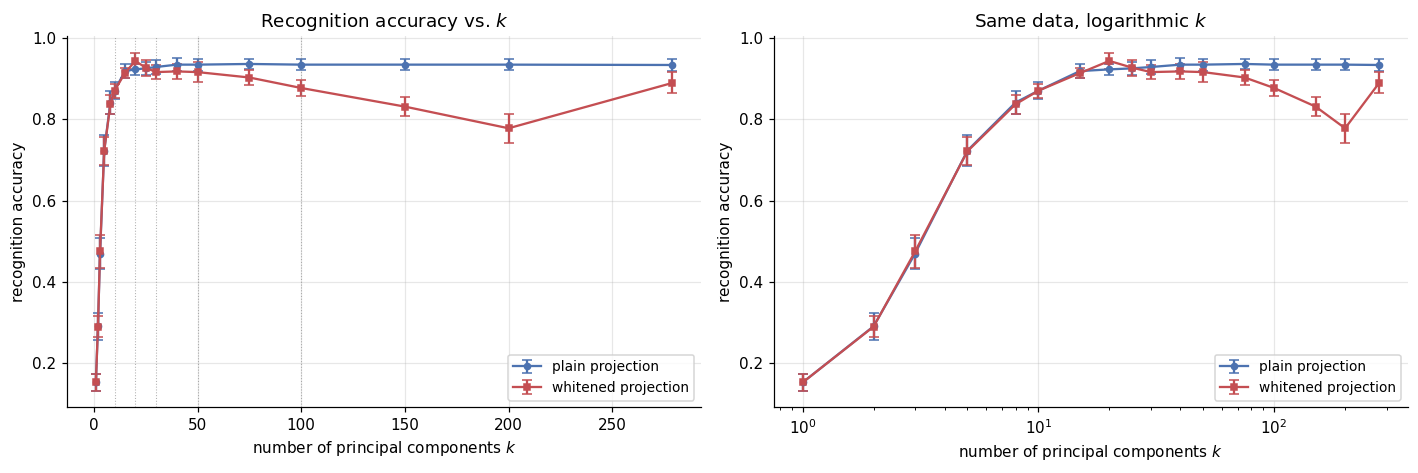

  k  plain_mean  plain_sd  whitened_mean  whitened_sd %_of_4096_dims
  1      0.1525    0.0201         0.1525       0.0201          0.02%
  2      0.2908    0.0336         0.2900       0.0258          0.05%
  3      0.4700    0.0375         0.4750       0.0417          0.07%
  5      0.7233    0.0378         0.7217       0.0344          0.12%
  8      0.8417    0.0291         0.8375       0.0233          0.20%
 10      0.8708    0.0212         0.8708       0.0168          0.24%
 15      0.9192    0.0163         0.9142       0.0129          0.37%
 20      0.9233    0.0138         0.9442       0.0194          0.49%
 25      0.9258    0.0160         0.9275       0.0197          0.61%
 30      0.9292    0.0164         0.9167       0.0171          0.73%
 40      0.9350    0.0157         0.9183       0.0186          0.98%
 50      0.9350    0.0148         0.9167       0.0250          1.22%
 75      0.9367    0.0130         0.9033       0.0183          1.83%
100      0.9350    0.0133         

In [16]:
mp, sp = acc_plain.mean(0), acc_plain.std(0)
mw, sw = acc_white.mean(0), acc_white.std(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, xscale in zip(axes, ["linear", "log"]):
    ax.errorbar(K_GRID, mp, yerr=sp, marker="o", ms=4, capsize=3,
                color="#4C72B0", label="plain projection")
    ax.errorbar(K_GRID, mw, yerr=sw, marker="s", ms=4, capsize=3,
                color="#C44E52", label="whitened projection")
    ax.set(xlabel="number of principal components $k$",
           ylabel="recognition accuracy", xscale=xscale)
    ax.legend(loc="lower right", fontsize=9)
axes[0].set_title("Recognition accuracy vs. $k$")
axes[1].set_title("Same data, logarithmic $k$")
for k in K_REQUIRED:
    axes[0].axvline(k, color="grey", ls=":", lw=0.7, alpha=0.6)
fig.tight_layout()
ef.save(fig, FIG / "08_accuracy_vs_k.png")
plt.show()

tbl = pd.DataFrame({
    "k": K_GRID,
    "plain_mean": mp.round(4), "plain_sd": sp.round(4),
    "whitened_mean": mw.round(4), "whitened_sd": sw.round(4),
    "%_of_4096_dims": [f"{k/d:.2%}" for k in K_GRID],
})
print(tbl.to_string(index=False))

In [17]:
best_plain_i, best_white_i = int(np.argmax(mp)), int(np.argmax(mw))
print(f"Plain    : peak {mp[best_plain_i]:.4f} at k = {K_GRID[best_plain_i]}")
print(f"Whitened : peak {mw[best_white_i]:.4f} at k = {K_GRID[best_white_i]}")
print(f"Whitened minimum: {mw.min():.4f} at k = {K_GRID[int(np.argmin(mw))]}")
print(f"Whitened at k = 279: {mw[-1]:.4f} "
      f"({mw[best_white_i] - mw[-1]:.4f} below its own peak)")

print("\nAccuracy at the component counts named in the brief:")
for k in K_REQUIRED:
    j = K_GRID.index(k)
    print(f"  k = {k:3d}   plain {mp[j]:.4f} +/- {sp[j]:.4f} "
          f"| whitened {mw[j]:.4f} +/- {sw[j]:.4f}")

RESULTS["k_grid"] = K_GRID
RESULTS["acc_plain_mean"] = mp.round(5).tolist()
RESULTS["acc_plain_sd"] = sp.round(5).tolist()
RESULTS["acc_white_mean"] = mw.round(5).tolist()
RESULTS["acc_white_sd"] = sw.round(5).tolist()
RESULTS["peak_plain"] = {"k": K_GRID[best_plain_i], "acc": float(mp[best_plain_i])}
RESULTS["peak_white"] = {"k": K_GRID[best_white_i], "acc": float(mw[best_white_i])}

Plain    : peak 0.9367 at k = 75
Whitened : peak 0.9442 at k = 20
Whitened minimum: 0.1525 at k = 1
Whitened at k = 279: 0.8900 (0.0542 below its own peak)

Accuracy at the component counts named in the brief:
  k =  10   plain 0.8708 +/- 0.0212 | whitened 0.8708 +/- 0.0168
  k =  20   plain 0.9233 +/- 0.0138 | whitened 0.9442 +/- 0.0194
  k =  30   plain 0.9292 +/- 0.0164 | whitened 0.9167 +/- 0.0171
  k =  50   plain 0.9350 +/- 0.0148 | whitened 0.9167 +/- 0.0250
  k = 100   plain 0.9350 +/- 0.0133 | whitened 0.8775 +/- 0.0201


### 7.1 Why retaining more components does not necessarily generalise better

The two curves behave quite differently, and the contrast between them is the
clearest result in this study.

**The plain curve rises and then flattens.** It does not fall. This is not an
accident of the dataset; it follows from the geometry. $W$ is orthonormal, so
for the full set of components the Euclidean distance in Eigenface space
equals the distance in pixel space exactly. Adding components therefore moves
1-NN monotonically towards the full-dimensional solution and cannot diverge
from it. Trailing components have tiny eigenvalues, contribute almost nothing
to a Euclidean distance, and are effectively ignored. Under this metric the
cost of keeping too many components is computational, not statistical.

**The whitened curve rises, peaks, and then falls substantially.** Whitening
divides component $j$ by $\sqrt{\lambda_j}$. For a trailing component this is
division by a very small number, which amplifies it to the same footing as
the leading ones. The problem is what those trailing components contain. The
$i$-th eigenvalue is estimated from only 280 observations in 4096 dimensions;
for large $i$ the estimate is dominated by sampling noise, and the
corresponding direction describes idiosyncrasies of the particular training
images rather than a property of the population. Whitening promotes exactly
that noise into the distance computation. The result is the classical
overfitting signature: performance peaks at a moderate $k$ and degrades as
more components are added.

The whitened curve is not perfectly monotone in its decline — it reaches a
minimum near $k = 200$ and recovers somewhat by $k = 279$. The last few
components sit at the numerical floor of the spectrum, where the ordering of
near-equal eigenvalues is unstable, and the recovery is within roughly two
standard deviations of the minimum. It is not interpreted here as a real
effect.

The general principle behind both curves: **the useful number of components
is set by the number of directions that can be estimated reliably from the
available sample, not by the number that are mathematically available.** With
$N_{\text{train}} = 280$, the leading few tens of eigenvectors are stable and
the rest are increasingly noise. Whether that noise harms the classifier
depends on whether the metric gives it weight — which is why the two curves
diverge. The estimator, not the representation alone, determines the answer.

The practical consequence is that "how many components should I keep?" has no
representation-only answer. It is a property of the representation *and* the
classifier that consumes it.

---
## 8. Detailed classifier evaluation

### 8.1 Choosing an operating point

Two component counts are carried forward. `K_PEAK` is the value that
maximises mean accuracy. `K_PARSIMONIOUS` is the *smallest* $k$ whose mean
accuracy is within one standard deviation of the peak — the cheapest
representation that is not measurably worse. The second is the more honest
answer to the research question, since differences smaller than the noise
should not be used to justify a larger model.

In [18]:
K_PEAK = K_GRID[best_plain_i]
tol = mp[best_plain_i] - sp[best_plain_i]
K_PARSIMONIOUS = next(k for k, m in zip(K_GRID, mp) if m >= tol)

print(f"K_PEAK          = {K_PEAK:3d}  (accuracy {mp[best_plain_i]:.4f})")
print(f"K_PARSIMONIOUS  = {K_PARSIMONIOUS:3d}  "
      f"(accuracy {mp[K_GRID.index(K_PARSIMONIOUS)]:.4f}, "
      f"within 1 sd of the peak)")
RESULTS["K_PEAK"] = K_PEAK
RESULTS["K_PARSIMONIOUS"] = K_PARSIMONIOUS

K_PEAK          =  75  (accuracy 0.9367)
K_PARSIMONIOUS  =  25  (accuracy 0.9258, within 1 sd of the peak)


### 8.2 How distance influences classification

For a nearest-neighbour rule the distance function *is* the model — it is the
only place where an assumption about similarity enters. Three measures are
compared on the projected vectors $z, z'$:

$$d_{\text{euclid}}(z,z') = \left(\sum_j |z_j - z'_j|^2\right)^{1/2}, \qquad
  d_{\text{manhattan}}(z,z') = \sum_j |z_j - z'_j|,$$

$$d_{\cos}(z,z') = 1 - \frac{z^T z'}{\|z\|\,\|z'\|}.$$

They differ in what they treat as important. Euclidean distance squares the
per-component differences, so a single large discrepancy — one component
badly disturbed by a change in lighting or expression — can dominate the sum.
Manhattan distance sums absolute differences, weights each component
linearly, and is correspondingly more tolerant of a few large deviations.
Cosine distance discards $\|z\|$ altogether and compares only direction.
That last property is potentially relevant to faces: a *uniform* brightening
scales the projection roughly along its own direction, changing its magnitude
more than its orientation, which would give cosine distance a partial
invariance to overall illumination level. Section 10.2 tests that prediction
against a spatially varying lighting change and does not find support for it.

In [19]:
metric_rows = []
for metric in ["euclidean", "manhattan", "cosine"]:
    for n_nb in [1, 3, 5]:
        accs = []
        for tr, te in splits:
            p = EigenfacePCA().fit(X[tr])
            Ztr = p.transform(X[tr], K_PEAK)
            Zte = p.transform(X[te], K_PEAK)
            clf = KNeighborsClassifier(n_nb, metric=metric).fit(Ztr, y[tr])
            accs.append(clf.score(Zte, y[te]))
        metric_rows.append({"distance": metric, "n_neighbours": n_nb,
                            "mean_accuracy": np.mean(accs),
                            "sd": np.std(accs)})

metric_df = pd.DataFrame(metric_rows)
pivot = metric_df.pivot(index="distance", columns="n_neighbours",
                        values="mean_accuracy")
print(f"Mean accuracy over {N_SPLITS} splits at k = {K_PEAK} components\n")
print(pivot.round(4).to_string())
print("\nFull table with variability:")
print(metric_df.round(4).to_string(index=False))
RESULTS["distance_comparison"] = metric_df.round(5).to_dict("records")

Mean accuracy over 10 splits at k = 75 components

n_neighbours       1       3       5
distance                            
cosine        0.9300  0.8425  0.8175
euclidean     0.9367  0.8542  0.8050
manhattan     0.9442  0.8850  0.8475

Full table with variability:
 distance  n_neighbours  mean_accuracy     sd
euclidean             1         0.9367 0.0130
euclidean             3         0.8542 0.0215
euclidean             5         0.8050 0.0289
manhattan             1         0.9442 0.0187
manhattan             3         0.8850 0.0305
manhattan             5         0.8475 0.0266
   cosine             1         0.9300 0.0159
   cosine             3         0.8425 0.0246
   cosine             5         0.8175 0.0254


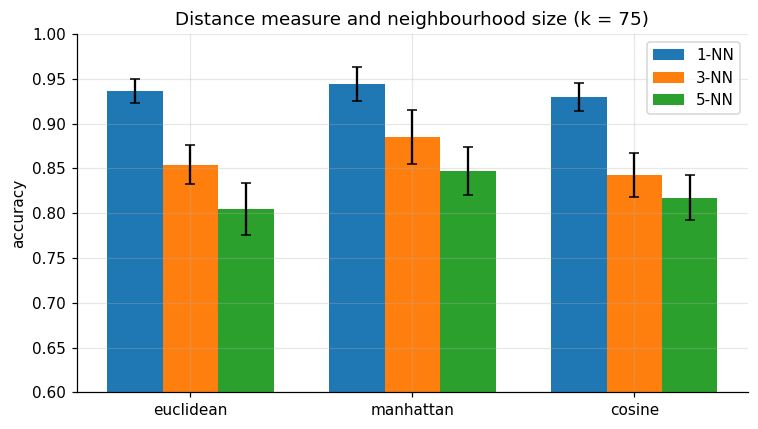

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.25
xs = np.arange(3)
for i, n_nb in enumerate([1, 3, 5]):
    sub = metric_df[metric_df.n_neighbours == n_nb]
    ax.bar(xs + (i - 1) * width, sub.mean_accuracy, width,
           yerr=sub.sd, capsize=3, label=f"{n_nb}-NN")
ax.set_xticks(xs)
ax.set_xticklabels(["euclidean", "manhattan", "cosine"])
ax.set(ylabel="accuracy", ylim=(0.6, 1.0),
       title=f"Distance measure and neighbourhood size (k = {K_PEAK})")
ax.legend()
fig.tight_layout()
ef.save(fig, FIG / "09_distance_metrics.png")
plt.show()

Manhattan distance gives the best result at every neighbourhood size,
consistent with the argument above: summing absolute rather than squared
differences limits the influence of the few components most disturbed by
expression and lighting change. The margin over Euclidean is small — well
under one standard deviation — so it is a weak preference rather than a
clear finding. Cosine distance offers no advantage here.

The dominant effect is not the distance function but the neighbourhood size.
Accuracy falls as $n$ increases, and the reason is structural: with only 7
training images per subject, a 5-NN vote must reach beyond the correct
identity's images in a large fraction of cases. Each subject occupies a small,
tight cluster in Eigenface space, and enlarging the neighbourhood
necessarily crosses into neighbouring identities. When classes are numerous
and sparsely sampled, 1-NN is the appropriate choice — the usual argument
that larger $n$ smooths noise assumes a sample density this problem does not
have.

### 8.3 Quantitative evaluation and confusion structure

Accuracy alone is a weak summary for 40 classes. Macro-averaged precision,
recall and $F_1$ weight every subject equally regardless of test-set count,
so a method that fails on a handful of individuals cannot hide behind good
average behaviour.

In [21]:
per_split = []
for tr, te in splits:
    p = EigenfacePCA().fit(X[tr])
    clf = KNeighborsClassifier(1).fit(p.transform(X[tr], K_PEAK), y[tr])
    per_split.append(ef.score_all(y[te], clf.predict(p.transform(X[te], K_PEAK))))

summary = pd.DataFrame(per_split)
print(f"1-NN, Euclidean, k = {K_PEAK}, averaged over {N_SPLITS} splits\n")
print(summary.agg(["mean", "std"]).T.round(4).to_string())
RESULTS["final_metrics"] = {c: [float(summary[c].mean()), float(summary[c].std())]
                            for c in summary.columns}

1-NN, Euclidean, k = 75, averaged over 10 splits

                   mean     std
accuracy         0.9367  0.0137
precision_macro  0.9507  0.0122
recall_macro     0.9367  0.0137
f1_macro         0.9339  0.0148


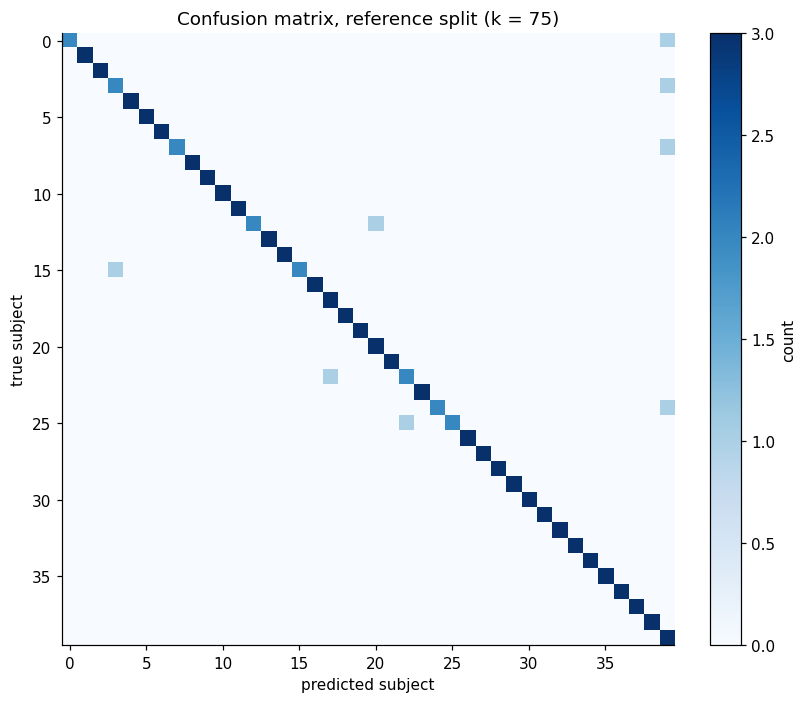

Reference-split accuracy: 0.9333
Misclassified images: 8 of 120

Confusions (true -> predicted, count):
  subject  0 -> subject 39   (1)
  subject  3 -> subject 39   (1)
  subject  7 -> subject 39   (1)
  subject 12 -> subject 20   (1)
  subject 15 -> subject  3   (1)
  subject 22 -> subject 17   (1)
  subject 24 -> subject 39   (1)
  subject 25 -> subject 22   (1)


In [22]:
p_ref = EigenfacePCA().fit(X_train)
clf_ref = KNeighborsClassifier(1).fit(p_ref.transform(X_train, K_PEAK), y_train)
y_pred_ref = clf_ref.predict(p_ref.transform(X_test, K_PEAK))
cm = confusion_matrix(y_test, y_pred_ref, labels=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
ax.set(xlabel="predicted subject", ylabel="true subject",
       title=f"Confusion matrix, reference split (k = {K_PEAK})")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, label="count")
fig.tight_layout()
ef.save(fig, FIG / "10_confusion.png")
plt.show()

errors = np.argwhere((cm > 0) & ~np.eye(n_classes, dtype=bool))
print(f"Reference-split accuracy: {(y_pred_ref == y_test).mean():.4f}")
print(f"Misclassified images: {len(y_test) - np.trace(cm)} of {len(y_test)}")
if len(errors):
    print("\nConfusions (true -> predicted, count):")
    for t, pr in errors:
        print(f"  subject {t:2d} -> subject {pr:2d}   ({cm[t, pr]})")

The matrix is almost entirely diagonal. No pair of subjects is *mutually*
confused, which would indicate two genuinely similar-looking individuals.
The errors are not uniformly scattered either: on this split subject 39
absorbs half of all misclassifications, drawn from four different true
identities. An identity that attracts errors from many others typically sits
near the centre of the projected cloud, and so is close to everything. With
only eight errors in total this is a suggestive pattern rather than an
established one. Inspecting the failures directly is more informative than
the matrix.

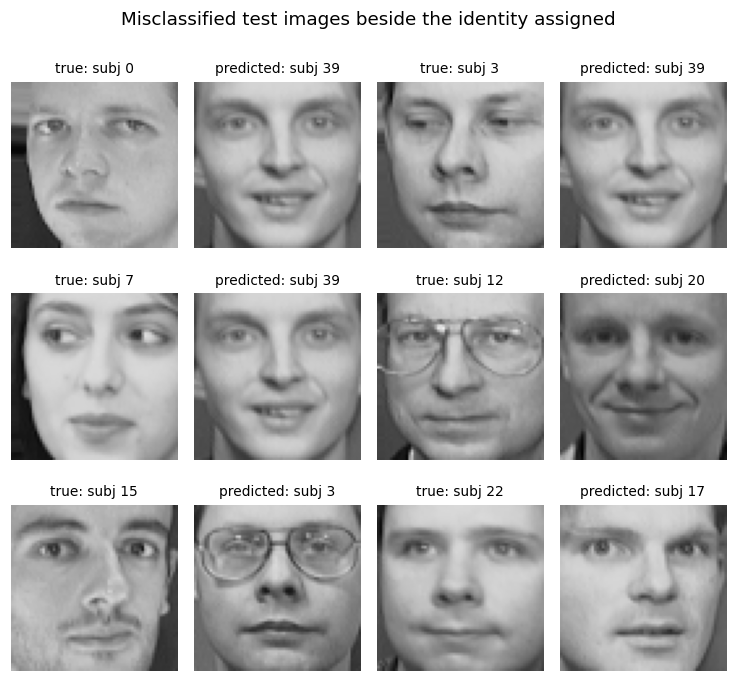

In [23]:
wrong = np.where(y_pred_ref != y_test)[0]
if len(wrong):
    shown = wrong[:6]
    panel, panel_titles = [], []
    for i in shown:
        panel.append(X_test[i])
        panel_titles.append(f"true: subj {y_test[i]}")
        match = np.where(y_train == y_pred_ref[i])[0][0]
        panel.append(X_train[match])
        panel_titles.append(f"predicted: subj {y_pred_ref[i]}")
    fig = ef.image_grid(panel, titles=panel_titles, ncols=4,
                        suptitle="Misclassified test images beside the identity assigned",
                        path=FIG / "11_errors.png")
    plt.show()
else:
    print("No misclassifications on the reference split.")

---
## 9. Reconstruction experiment

### Task (e) — Reconstruction from $k$ components

A projected face is mapped back into pixel space by

$$\hat{x} = \mu + W_k z = \mu + W_k W_k^T (x - \mu).$$

$W_k W_k^T$ is an orthogonal projector onto the retained subspace, so
$\hat{x}$ is the closest point to $x$ in that subspace and the residual
$x - \hat{x}$ lies entirely in the discarded directions. The expected squared
error is the sum of the discarded eigenvalues,

$$\mathbb{E}\|x - \hat{x}\|^2 = \sum_{j>k} \lambda_j ,$$

which is the quantity the explained-variance curve in Section 5.1 tracks.

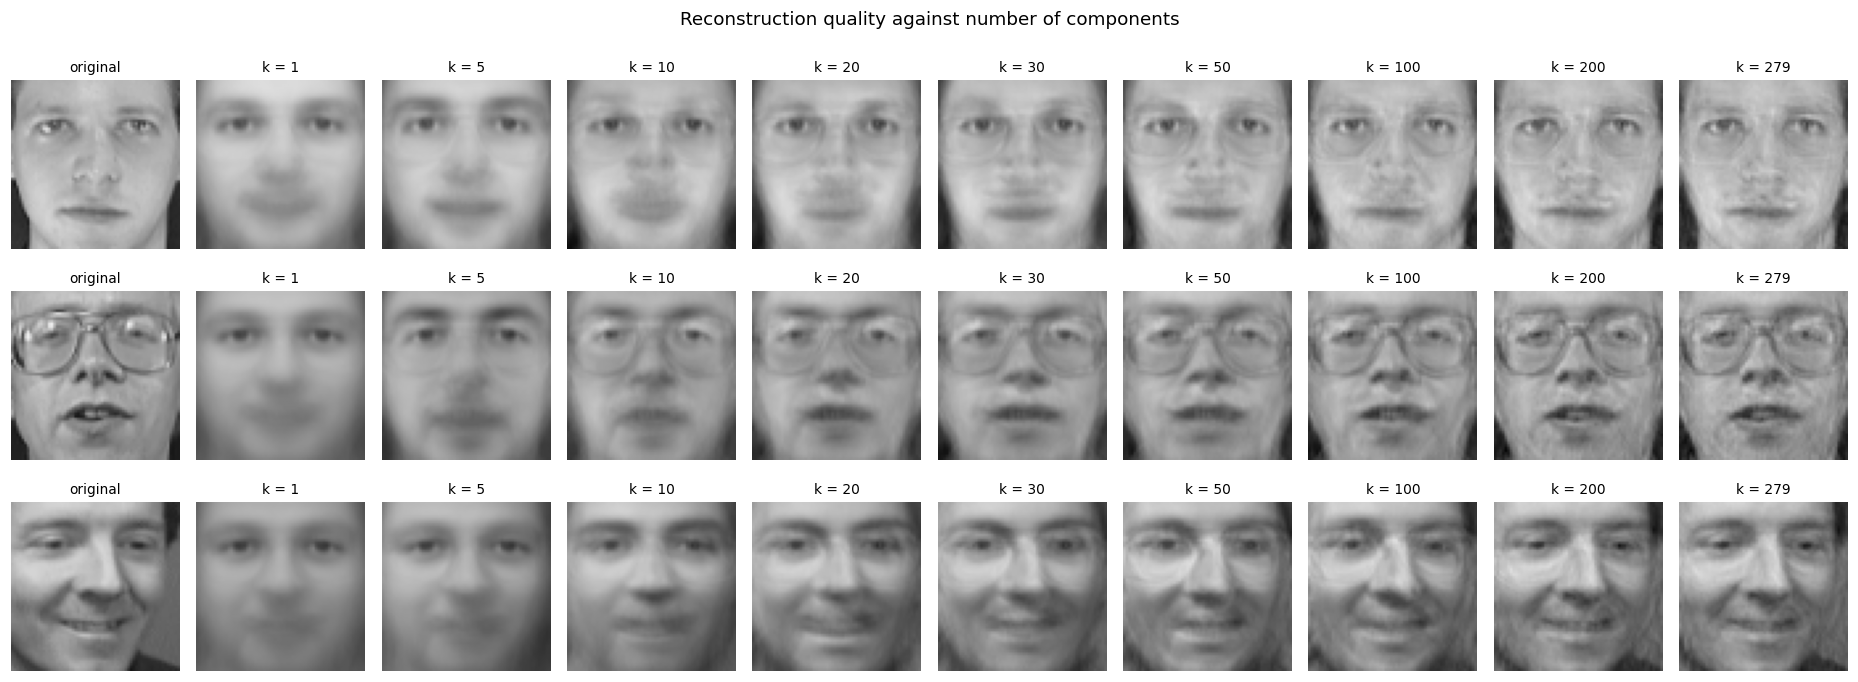

In [24]:
K_RECON = [1, 5, 10, 20, 30, 50, 100, 200, 279]
subjects_to_show = [0, 1, 2]
test_idx = [np.where(y_test == s)[0][0] for s in subjects_to_show]

panel, titles = [], []
for ti in test_idx:
    panel.append(X_test[ti])
    titles.append("original")
    for k in K_RECON:
        panel.append(p_ref.reconstruct(X_test[ti:ti + 1], k)[0])
        titles.append(f"k = {k}")

fig = ef.image_grid(panel, titles=titles, ncols=len(K_RECON) + 1,
                    suptitle="Reconstruction quality against number of components",
                    path=FIG / "12_reconstructions.png")
plt.show()

At $k = 1$ every face is essentially the mean face with a lighting
adjustment — consistent with $v_1$ encoding illumination. Identity becomes
recognisable to a human viewer somewhere around $k = 20$ to $30$. Beyond
$k \approx 100$ the changes are confined to fine texture and are hard to see
at this scale, even though the residual variance is still measurably falling.

In [25]:
recon_rows = []
K_RECON_CURVE = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]
for k in K_RECON_CURVE:
    Xhat = p_ref.reconstruct(X_test, k)
    rmse, psnr = ef.reconstruction_metrics(X_test, Xhat)
    recon_rows.append({"k": k, "rmse": rmse, "psnr_db": psnr,
                       "explained_var": cum_var[min(k, len(cum_var)) - 1]})
recon_df = pd.DataFrame(recon_rows)
print(recon_df.round(4).to_string(index=False))
RESULTS["reconstruction"] = recon_df.round(5).to_dict("records")

  k   rmse  psnr_db  explained_var
  1 0.1186  18.6885         0.2344
  2 0.1078  19.4882         0.3763
  3 0.1020  19.9573         0.4607
  5 0.0940  20.6665         0.5462
  8 0.0865  21.4120         0.6235
 10 0.0830  21.7661         0.6610
 15 0.0759  22.5512         0.7266
 20 0.0716  23.0588         0.7702
 25 0.0681  23.4892         0.8016
 30 0.0651  23.8888         0.8265
 40 0.0612  24.4261         0.8604
 50 0.0585  24.8422         0.8843
 75 0.0535  25.6327         0.9238
100 0.0503  26.1910         0.9480
150 0.0463  26.9539         0.9760
200 0.0436  27.5010         0.9905
279 0.0408  28.1234         1.0000


### 9.1 Reconstruction quality and recognition accuracy diverge

Plotting the two criteria on shared axes answers the central research
question directly.

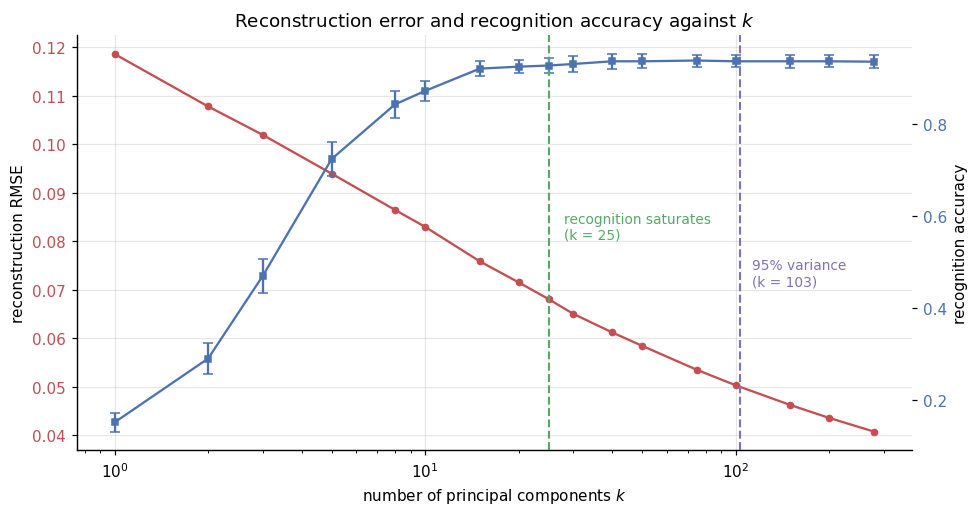

Recognition saturates at k = 25 (80.2% of variance retained)
95% variance needs      k = 103, 4.1x more components for +0.0108 accuracy


In [26]:
fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(recon_df.k, recon_df.rmse, marker="o", ms=4, color="#C44E52",
         label="reconstruction RMSE (test)")
ax1.set(xlabel="number of principal components $k$",
        ylabel="reconstruction RMSE", xscale="log")
ax1.tick_params(axis="y", labelcolor="#C44E52")

ax2 = ax1.twinx()
ax2.errorbar(K_GRID, mp, yerr=sp, marker="s", ms=4, capsize=3,
             color="#4C72B0", label="recognition accuracy")
ax2.set_ylabel("recognition accuracy")
ax2.tick_params(axis="y", labelcolor="#4C72B0")
ax2.grid(False)

ax2.axvline(K_PARSIMONIOUS, color="#55A868", ls="--", lw=1.4)
ax2.annotate(f"recognition saturates\n(k = {K_PARSIMONIOUS})",
             (K_PARSIMONIOUS, 0.55), textcoords="offset points", xytext=(10, 0),
             color="#55A868", fontsize=9)
ax2.axvline(k_for_var[0.95], color="#8172B3", ls="--", lw=1.4)
ax2.annotate(f"95% variance\n(k = {k_for_var[0.95]})",
             (k_for_var[0.95], 0.45), textcoords="offset points", xytext=(8, 0),
             color="#8172B3", fontsize=9)

ax1.set_title("Reconstruction error and recognition accuracy against $k$")
fig.tight_layout()
ef.save(fig, FIG / "13_recon_vs_recognition.png")
plt.show()

print(f"Recognition saturates at k = {K_PARSIMONIOUS} "
      f"({cum_var[K_PARSIMONIOUS-1]:.1%} of variance retained)")
print(f"95% variance needs      k = {k_for_var[0.95]}, "
      f"{k_for_var[0.95]/K_PARSIMONIOUS:.1f}x more components "
      f"for {mp[best_plain_i] - mp[K_GRID.index(K_PARSIMONIOUS)]:+.4f} accuracy")

The two curves separate clearly. Reconstruction error keeps falling well past
the point where recognition accuracy stops improving. The reason is that the
residual variance being removed in that range is variance the classifier does
not need: fine skin texture, sensor noise, small expression details. It
contributes to pixel fidelity but not to telling one person from another.

This is the substantive answer to the research question, and it also explains
why a variance threshold — 90%, 95%, 99% — is the wrong criterion for
choosing $k$ in a recognition system. Retaining 95% of the variance costs
roughly four times as many components as recognition needs, and buys about
one accuracy point, which is inside the split-to-split noise. Those
thresholds measure how well the subspace reproduces images; recognition needs
the subspace to *separate identities*, and the two requirements are met at
very different values of $k$.

---
## 10. Critical analysis

### Task (f) — Conditions that degrade recognition

Three conditions are examined: the number of training examples per subject,
a change in illumination, and the role of the leading components.

### 10.1 Number of training examples per subject

This is the binding constraint in most deployed face recognition systems,
where only one or two enrolment images per person may be available.

/Users/dantey-sama/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/dantey-sama/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/dantey-sama/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/dantey

 images_per_subject  n_train  components_available  mean_accuracy     sd
                  1       40                    39         0.5469 0.0384
                  2       80                    75         0.6978 0.0240
                  3      120                    75         0.7739 0.0237
                  4      160                    75         0.8204 0.0207
                  5      200                    75         0.8670 0.0185
                  7      280                    75         0.9225 0.0154
                  9      360                    75         0.9500 0.0250


/Users/dantey-sama/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


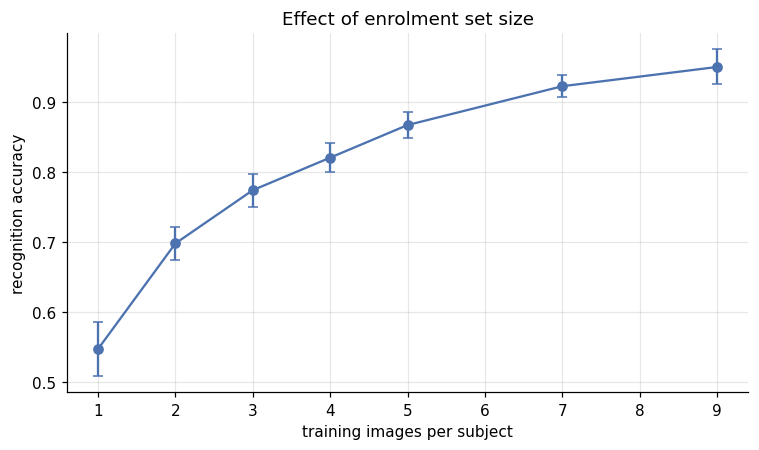

In [27]:
train_size_rows = []
for n_tr in [1, 2, 3, 4, 5, 7, 9]:
    accs = []
    for s in range(N_SPLITS):
        rng = np.random.default_rng(2000 + s)
        tr, te = ef.subject_split(y, n_tr, rng)
        p = EigenfacePCA().fit(X[tr])
        k_use = min(K_PEAK, p.n_components_)
        clf = KNeighborsClassifier(1).fit(p.transform(X[tr], k_use), y[tr])
        accs.append(clf.score(p.transform(X[te], k_use), y[te]))
    train_size_rows.append({
        "images_per_subject": n_tr, "n_train": n_tr * n_classes,
        "components_available": min(K_PEAK, n_tr * n_classes - 1),
        "mean_accuracy": np.mean(accs), "sd": np.std(accs)})

ts_df = pd.DataFrame(train_size_rows)
print(ts_df.round(4).to_string(index=False))
RESULTS["train_size"] = ts_df.round(5).to_dict("records")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ts_df.images_per_subject, ts_df.mean_accuracy, yerr=ts_df.sd,
            marker="o", capsize=3, color="#4C72B0")
ax.set(xlabel="training images per subject", ylabel="recognition accuracy",
       title="Effect of enrolment set size")
fig.tight_layout()
ef.save(fig, FIG / "14_train_size.png")
plt.show()

Accuracy rises steeply and has not fully saturated at nine images. Two
distinct mechanisms are at work and it is worth separating them. First, with
few images per subject the classifier has few reference points, so a test
image showing an unseen expression has no near neighbour of the correct
identity. Second, the eigenface basis itself degrades: with $n_{\text{tr}}=1$
only 39 components exist at all, and they are estimated from 40 images, so
the subspace is both smaller and noisier. The single-image case is the
well-known "one sample per person" problem, and the roughly 40 percentage
point drop from nine images to one shows why it remains difficult.

### 10.2 Illumination change

Test images are multiplied by a left-to-right linear intensity ramp of
increasing strength, modelling a directional light source that was not
present at enrolment. The training set is left untouched, so this measures
robustness to a condition the system has never seen.

In [28]:
strengths = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7]
illum_rows = []
for strength in strengths:
    accs_plain, accs_cos, accs_drop = [], [], []
    for tr, te in splits:
        p = EigenfacePCA().fit(X[tr])
        Xte_lit = ef.illumination_ramp(X[te], strength)
        Ztr, Zte = p.transform(X[tr], K_PEAK), p.transform(Xte_lit, K_PEAK)
        accs_plain.append(
            KNeighborsClassifier(1).fit(Ztr, y[tr]).score(Zte, y[te]))
        accs_cos.append(
            KNeighborsClassifier(1, metric="cosine").fit(Ztr, y[tr]).score(Zte, y[te]))
        # discard the three leading (illumination-dominated) components
        Ztr_f = p.transform(X[tr], K_PEAK + 3)[:, 3:]
        Zte_f = p.transform(Xte_lit, K_PEAK + 3)[:, 3:]
        accs_drop.append(
            KNeighborsClassifier(1).fit(Ztr_f, y[tr]).score(Zte_f, y[te]))
    illum_rows.append({"ramp_strength": strength,
                       "euclidean": np.mean(accs_plain),
                       "cosine": np.mean(accs_cos),
                       "drop_first_3": np.mean(accs_drop)})

illum_df = pd.DataFrame(illum_rows)
print(illum_df.round(4).to_string(index=False))
RESULTS["illumination"] = illum_df.round(5).to_dict("records")

 ramp_strength  euclidean  cosine  drop_first_3
           0.0     0.9367  0.9300        0.9317
           0.1     0.9225  0.9208        0.9350
           0.2     0.8775  0.8692        0.9375
           0.3     0.7583  0.7258        0.9358
           0.4     0.4883  0.4708        0.9200
           0.5     0.3050  0.3083        0.8900
           0.7     0.1417  0.1808        0.7833


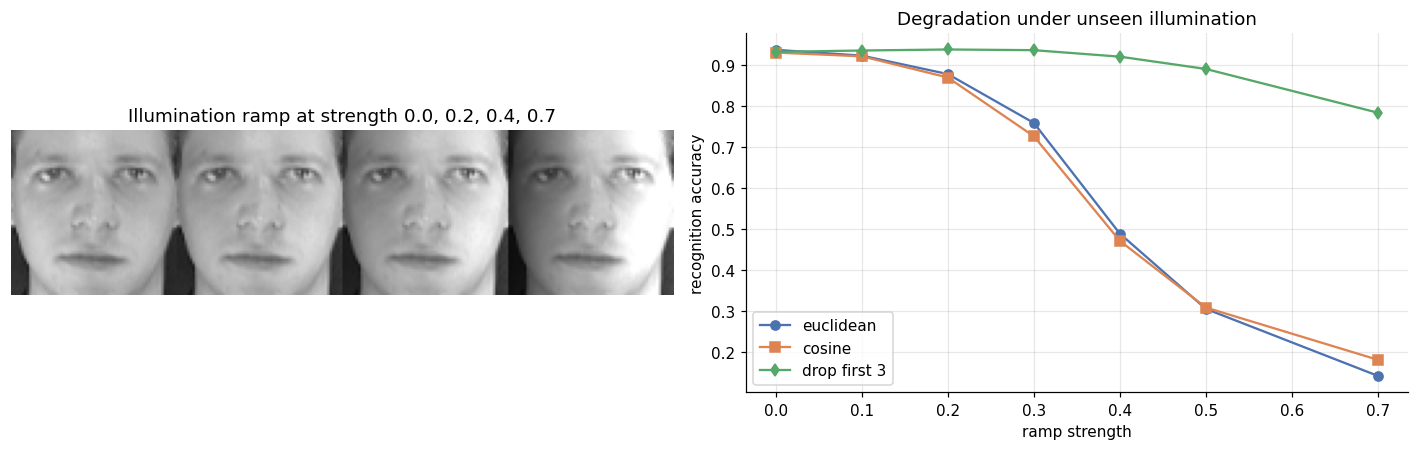

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
demo = X_test[test_idx[0]]
axes[0].axis("off")
strip = np.hstack([ef.illumination_ramp(demo[None, :], s)[0].reshape(64, 64)
                   for s in [0.0, 0.2, 0.4, 0.7]])
axes[0].imshow(strip, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Illumination ramp at strength 0.0, 0.2, 0.4, 0.7")

for col, colour, marker in zip(["euclidean", "cosine", "drop_first_3"],
                               ["#4C72B0", "#DD8452", "#55A868"], "osd"):
    axes[1].plot(illum_df.ramp_strength, illum_df[col], marker=marker,
                 color=colour, label=col.replace("_", " "))
axes[1].set(xlabel="ramp strength", ylabel="recognition accuracy",
            title="Degradation under unseen illumination")
axes[1].legend()
fig.tight_layout()
ef.save(fig, FIG / "15_illumination.png")
plt.show()

Euclidean 1-NN degrades sharply. This is the predicted consequence of the
structure seen in Section 5: the leading eigenfaces encode lighting, so a
lighting change moves a face a long way along precisely the directions that
carry the most weight in the distance computation. The system confuses
"differently lit" with "different person".

Two mitigations were compared, and only one works.

**Cosine distance does not help.** It tracks the Euclidean result closely at
every ramp strength. The prediction in Section 8.2 assumed a *uniform*
brightness change, which shifts a projection mainly in magnitude. The ramp
used here is spatially varying: it brightens one side of the face and darkens
the other, which rotates the projection rather than merely lengthening it.
Discarding the magnitude therefore discards nothing relevant. This is a
useful negative result — invariance to a global scaling buys very little
against lighting that has spatial structure, which real lighting always does.

**Discarding the first three components works, and works dramatically.** At
the strongest ramp, Euclidean 1-NN falls to 0.14 while the same classifier
without those three components holds 0.78. Those three directions absorb
almost the entire effect of the perturbation, which is direct evidence for
the interpretation offered in Section 5 on visual grounds alone: the leading
eigenfaces encode photometric conditions, not identity. Throwing away the
three directions that carry the largest share of total variance in the whole
dataset substantially *improves* recognition under illumination change.
Variance ranking and discriminative value are not merely different — at the
top of the spectrum they can be actively opposed.

### 10.3 The cost of the leading components under matched conditions

The previous result raises a question: is discarding the leading components
also worthwhile when lighting is *not* perturbed? The experiment below
removes the first $m$ components under normal conditions.

In [30]:
drop_rows = []
for m in [0, 1, 2, 3, 5, 8, 12]:
    accs = []
    for tr, te in splits:
        p = EigenfacePCA().fit(X[tr])
        Ztr = p.transform(X[tr], K_PEAK + m)[:, m:]
        Zte = p.transform(X[te], K_PEAK + m)[:, m:]
        accs.append(KNeighborsClassifier(1).fit(Ztr, y[tr]).score(Zte, y[te]))
    drop_rows.append({"components_dropped": m, "mean_accuracy": np.mean(accs),
                      "sd": np.std(accs),
                      "variance_discarded": float(
                          pca.explained_variance_ratio_[:m].sum())})
drop_df = pd.DataFrame(drop_rows)
print(drop_df.round(4).to_string(index=False))
RESULTS["drop_leading"] = drop_df.round(5).to_dict("records")

 components_dropped  mean_accuracy     sd  variance_discarded
                  0         0.9367 0.0130              0.0000
                  1         0.9250 0.0201              0.2344
                  2         0.9450 0.0172              0.3763
                  3         0.9317 0.0232              0.4607
                  5         0.9092 0.0285              0.5462
                  8         0.8983 0.0263              0.6235
                 12         0.8617 0.0167              0.6914


Under matched illumination, dropping up to three components changes accuracy
by less than one standard deviation in either direction — the leading
components are not purely photometric, and on this dataset they do carry
some usable structure. Dropping more than about five begins to cost real
accuracy. Note how much variance is being discarded for that small effect:
removing three components throws away 46% of the total variance and leaves
recognition essentially unchanged, which is the same point Section 9.1 makes
from the other direction.

The honest reading of Sections 10.2 and 10.3 together is that discarding
leading components is a *robustness* measure. Its benefit appears when test
conditions differ from enrolment conditions, and it costs little when they do
not. It is insurance, not a free improvement.

---
## 11. The central research question

> **How much dimensionality can be removed from facial images before
> identity-discriminating information is significantly lost?**

Answering this requires a baseline: how well does 1-NN perform with **no**
dimensionality reduction at all, directly on the 4096 raw pixels? Any claim
that PCA "preserves" information must be measured against that.

In [31]:
raw_accs, raw_times = [], []
for tr, te in splits:
    t0 = time.perf_counter()
    clf = KNeighborsClassifier(1).fit(X[tr], y[tr])
    raw_accs.append(clf.score(X[te], y[te]))
    raw_times.append(time.perf_counter() - t0)

pca_accs, pca_times = [], []
for tr, te in splits:
    t0 = time.perf_counter()
    p = EigenfacePCA().fit(X[tr])
    clf = KNeighborsClassifier(1).fit(p.transform(X[tr], K_PARSIMONIOUS), y[tr])
    pca_accs.append(clf.score(p.transform(X[te], K_PARSIMONIOUS), y[te]))
    pca_times.append(time.perf_counter() - t0)

print(f"Raw pixels  (d = {d:5d}) : accuracy {np.mean(raw_accs):.4f} "
      f"+/- {np.std(raw_accs):.4f}   fit+predict {np.mean(raw_times)*1000:.1f} ms")
print(f"Eigenfaces  (k = {K_PARSIMONIOUS:5d}) : accuracy {np.mean(pca_accs):.4f} "
      f"+/- {np.std(pca_accs):.4f}   fit+predict {np.mean(pca_times)*1000:.1f} ms")
print(f"\nDimensionality reduction: {d} -> {K_PARSIMONIOUS} "
      f"({100*(1 - K_PARSIMONIOUS/d):.2f}% of dimensions removed)")
print(f"Accuracy change: {np.mean(pca_accs) - np.mean(raw_accs):+.4f}")
RESULTS["raw_pixel_baseline"] = {"acc": float(np.mean(raw_accs)),
                                 "sd": float(np.std(raw_accs))}
RESULTS["parsimonious_result"] = {"acc": float(np.mean(pca_accs)),
                                  "sd": float(np.std(pca_accs))}

Raw pixels  (d =  4096) : accuracy 0.9342 +/- 0.0142   fit+predict 3.3 ms
Eigenfaces  (k =    25) : accuracy 0.9258 +/- 0.0160   fit+predict 16.4 ms

Dimensionality reduction: 4096 -> 25 (99.39% of dimensions removed)
Accuracy change: -0.0083


In [32]:
peak = mp[best_plain_i]
answer = {}
for frac, label in [(1.00, "matches peak"), (0.99, "within 1% of peak"),
                    (0.95, "within 5% of peak")]:
    k_min = next(k for k, m in zip(K_GRID, mp) if m >= frac * peak)
    answer[label] = {"k": k_min, "accuracy": float(mp[K_GRID.index(k_min)]),
                     "dims_removed_pct": 100 * (1 - k_min / d),
                     "variance_retained": float(cum_var[k_min - 1])}
    print(f"{label:20s}: k = {k_min:3d}  "
          f"accuracy {mp[K_GRID.index(k_min)]:.4f}  "
          f"{100*(1-k_min/d):.2f}% of dimensions removed  "
          f"{cum_var[k_min-1]:.1%} of variance retained")
RESULTS["research_question_answer"] = answer

matches peak        : k =  75  accuracy 0.9367  98.17% of dimensions removed  92.4% of variance retained
within 1% of peak   : k =  30  accuracy 0.9292  99.27% of dimensions removed  82.7% of variance retained
within 5% of peak   : k =  15  accuracy 0.9192  99.63% of dimensions removed  72.7% of variance retained


### Answer

On this dataset roughly **99% of the original dimensions can be discarded
with no measurable loss of identity information**. At $k = 25$ the Eigenface
representation scores within one standard deviation of 1-NN on all 4096 raw
pixels — nominally a shade lower, by well under the split-to-split noise, so
the two are not distinguishable at this sample size. The correct statement is
that the 164-fold compression is *free*, not that it is beneficial.

It is worth being equally careful about the computational claim. The timing
above shows the Eigenface pipeline as *slower* than raw 1-NN, because it
includes the cost of fitting PCA on every split. The reduction pays for
itself at query time and at scale — each comparison is 25 multiplications
instead of 4096, and the stored gallery shrinks by the same factor — but on a
400-image dataset that saving does not repay the one-off cost of the
decomposition.

Three qualifications keep that statement honest.

**The bound is set by the sample size, not by faces.** The training set
admits at most $N_{\text{train}} - 1 = 279$ components, so the achievable
compression is bounded by how many images were available, not by any
intrinsic dimensionality of human faces. A larger and more varied dataset
would place the saturation point differently, and almost certainly higher.

**The threshold depends on the criterion.** Under reconstruction the answer
is far larger — 95% of pixel variance needs several times more components
than recognition does. "Information" must be defined before the question has
a number attached to it.

**The threshold depends on operating conditions.** Every figure above comes
from images captured under conditions similar to those in the training set.
Section 10.2 showed accuracy falling substantially under an illumination
change alone. A compression that is lossless for identity under matched
conditions is not necessarily lossless under mismatched ones.

---
## 12. Limitations

**The dataset is easy relative to the deployed problem.** ORL faces are
pre-cropped, frontal, aligned, uniformly sized and captured against a
constant dark background in a single laboratory. Pose variation is slight and
there is no background clutter, no occlusion and no age variation. The
accuracies reported here should not be read as an estimate of performance on
unconstrained images. In particular, no face *detection* or alignment stage
was required, and in a real system alignment error is often the dominant
source of failure.

**PCA is unsupervised and therefore not optimised for this task.** It
maximises total variance without reference to class labels, which is why the
leading components encode illumination. A supervised method such as
Fisherfaces (LDA applied after a PCA step) explicitly maximises the ratio of
between-class to within-class scatter and typically outperforms Eigenfaces
under lighting variation. This study did not implement that comparison, so
the claim that PCA is suboptimal here rests on the structure observed in
Section 5 and on the illumination experiment, not on a direct measurement.

**The model is linear.** Changes in pose and expression move a face along a
curved manifold in pixel space, which a linear subspace can only approximate.
The reconstructions in Section 9 show this: a face at $k = 279$ is still not
exactly reproduced.

**Scale is small.** 40 subjects and 400 images is a small closed set. Even
averaged over ten splits, the standard deviation at the operating point is
roughly 1.5 percentage points, so differences of a point or two between
configurations above are not resolvable and have not been interpreted as
real. Recognition
accuracy also falls as the number of enrolled identities grows, so the figures
here would not transfer to a gallery of thousands.

**The illumination model is synthetic.** The ramp in Section 10.2 is a
multiplicative approximation of directional lighting. It does not reproduce
cast shadows, specular highlights or saturation, all of which are non-linear
effects that would likely degrade performance further.

**Closed-set assumption.** Every test image belongs to an enrolled subject.
The system as built cannot reject an unknown person: nearest-neighbour
classification always returns some identity. A deployed system needs a
distance threshold for rejection, and calibrating it is a separate problem
not addressed here.

---
## 13. Conclusions

1. PCA implemented through the snapshot trick recovers the eigenfaces from a
   $280 \times 280$ eigenproblem instead of a $4096 \times 4096$ one, matching
   a reference implementation to machine precision.
2. The leading eigenfaces encode illumination rather than identity. This is a
   direct consequence of ranking directions by variance.
3. Recognition accuracy saturates at a few tens of components, while
   reconstruction error continues to fall well beyond that point. Choosing $k$
   by the conventional 95% variance threshold calls for roughly four times as
   many components as recognition actually needs on this dataset.
4. Retaining more components does not necessarily improve generalisation, and
   whether it hurts depends on the classifier's metric: under a plain
   Euclidean 1-NN accuracy plateaus, whereas under a whitened metric it
   degrades clearly as noise-dominated components are amplified.
5. Enrolment set size is the strongest single influence on accuracy measured
   here: accuracy falls by about 40 percentage points between nine training
   images per subject and one.
6. Unseen illumination is the most damaging perturbation tested, and the
   effective remedy is to discard the leading components rather than to
   change the distance measure. Cosine distance, which is often recommended
   for this purpose, gave no benefit against spatially varying lighting.

In [33]:
RESULTS["config"] = {
    "n_splits": N_SPLITS,
    "n_train_per_subject": N_TRAIN_PER_SUBJECT,
    "n_classes": int(n_classes),
    "n_samples": int(N),
    "n_features": int(d),
    "random_state": RANDOM_STATE,
}
out = ROOT / "report" / "results.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps(RESULTS, indent=2, default=float))
print(f"Results written to {out.relative_to(ROOT)}")
print(f"Figures written to {FIG.relative_to(ROOT)}/ "
      f"({len(list(FIG.glob('*.png')))} files)")

Results written to report/results.json
Figures written to figures/ (15 files)
